# RK4 particle 49: interactive gap viewer

Load the saved particle-49 trajectory and the original 48-particle RK4 context. **No integration is performed here.** Run [calculo.ipynb](calculo.ipynb) first if the result is absent.

The page contains one RK4 panel. Particle 49 is opaque magenta; all original particle IDs and colors are preserved. It opens on the selected region with all saved cycles visible.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from diagnostics.paths import find_project_root
from diagnostics.poincare_probe import load_rk4_probe, save_rk4_probe
from studies.poincare_periodicity import load_saved_poincare_section
from studies.poincare_probe import (
    RK4ProbeSettings, load_probe_field, probe_contract, integrate_rk4_probe,
    probe_section, probe_clearance, probe_comparison_panel,
)
from visualization.poincare_probe import plot_probe_context, display_probe_viewer, serve_probe_viewer
from visualization.poincare_comparison import export_poincare_panel_comparison

PROJECT_ROOT = find_project_root(Path.cwd())
BASE = PROJECT_ROOT / "notebooks/developements/poincare_section"
STUDY = BASE / "Poincare_RK4_particle_49_gap_5000_cycles_20_steps"
BACKGROUND_STUDY = BASE / "Poincare_RK4_48_radiales_5000_ciclos_20_steps_local"
BACKGROUND_RUN = "local_rk4_48p_5000c_20s_20260920"
RUN_DIRECTORY = STUDY / "results/rk4_particle49_5000c_20s"
VIEW = (0.396, 0.529, 0.119)  # Lower x/L, lower y/L, and square span/L.


Loaded RK4 particle 49: 5,000 cycles, 20 steps/cycle; color #d000d0


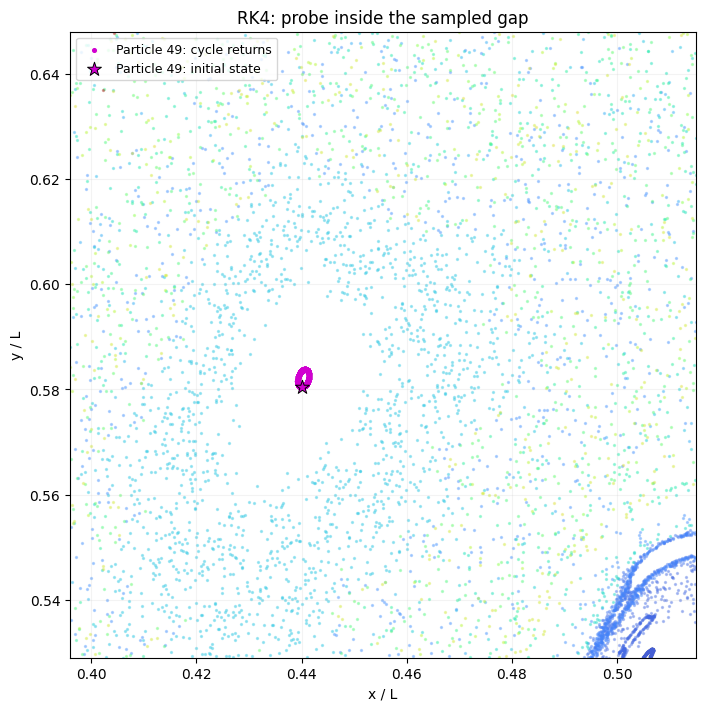

In [2]:
result, metadata = load_rk4_probe(RUN_DIRECTORY)
saved = metadata["contract"]
SETTINGS = RK4ProbeSettings(**saved["settings"])
background = load_saved_poincare_section(BACKGROUND_STUDY, BACKGROUND_RUN, tuple(range(1, 49)))
assert saved["method"] == background.metadata["method"] == "RK4"
assert saved["background_run_id"] == BACKGROUND_RUN
assert saved["background_sha256"] == background.source_hashes
assert saved["snapshot_sha256"] == background.metadata["snapshot_sha256"]
L = saved["field_provenance"]["grid"]["period"]
positions = probe_section(result, SETTINGS, L)
print(f"Loaded RK4 particle {SETTINGS.particle_id}: {SETTINGS.cycles:,} cycles, "
      f"{SETTINGS.steps_per_cycle} steps/cycle; color {SETTINGS.color}")
display(plot_probe_context(background, SETTINGS, view=VIEW, positions=positions))
plt.close("all")


## Export and open the URL

- **Only particle 49** isolates the new orbit; **Show all** restores its context.
- **Start cycle** and **Current cycle** select the displayed interval.
- **Selected region** restores the initial crop; **Full view** shows the complete periodic cell.
- Drag a square to zoom; Shift-drag or right-drag to pan. **Point size** adjusts visibility.

The HTML is self-contained, with no CDN dependency. Display coordinates use float32; the calculation archive stays float64. The local HTTP URL works on this computer while this notebook kernel is running. Reexecute the URL cell after restarting the kernel. The embedded preview also works without a separate browser tab.

In [3]:
OUTPUT_HTML = STUDY / "poincare_rk4_particle49.html"
panel = probe_comparison_panel(background, positions, SETTINGS)
export_poincare_panel_comparison(
    OUTPUT_HTML, [panel], cycles_per_frame=25,
    initial_view=VIEW, initial_cycle=SETTINGS.cycles,
    highlight_particle=SETTINGS.particle_id,
    title="RK4 Poincare section — particle 49 in the sampled gap",
)
print(f"Self-contained HTML: {OUTPUT_HTML}")


Self-contained HTML: /home/juagil@cartif.local/Investigaciones/GC2D/GC2D_codigo/notebooks/developements/poincare_section/Poincare_RK4_particle_49_gap_5000_cycles_20_steps/poincare_rk4_particle49.html


In [ ]:
VIEWER_URL = serve_probe_viewer(OUTPUT_HTML)
print(f"Local viewer URL: {VIEWER_URL}")
display_probe_viewer(OUTPUT_HTML, local_url=VIEWER_URL, height=1250)
